![banner](../../../../docs/figs/brand_identity/banner.png)

# Week 8: YOLO Object Detection and Tracking

## Lesson overview

Use YOLO to find and track pedestrians in video frames. The inputs are repository video files and model weights; the outputs are detection records, a heatmap, trajectory plots, and an annotated video.

**By the end, you can:** read locations and confidence scores in the detection table; check tracking results against the video; and explain how occlusion and missed detections affect trajectories.

**Before you begin:** Check that the repository videos and YOLO weights are available. Video processing creates large result files; the cells specify where they are saved.

<p align="center"><img src="../../../../docs/figs/yolo_tracking_storyboard.svg" alt="Real video frame with pedestrian boxes and IDs, example tracking rows, and path and heatmap displays" width="100%"><br><em>Figure 1. The Starter Kit storyboard traces a detection box to a CSV row, a track, and a heatmap.</em></p>

**Guiding question:** If the tracker changes a person’s ID after an occlusion, what will happen to the plotted trajectory?


## Step 1: Testing YOLO v11 of detecting and tracking pedestrain

Start by inspecting detections from a short video. Each row usually represents one object in one frame; box coordinates and confidence help you judge whether a detection looks reasonable.

In [1]:
import numpy as np
import pandas as pd
import os
from ultralytics import YOLO
from ccai9012 import yolo_utils
from ccai9012.paths import STARTER_KITS_DIR

In [3]:
# Load the local YOLOv11 model
base_dir = STARTER_KITS_DIR / "4_cv_models" / "webcam_yolo"
model = YOLO(str(base_dir / "yolo11m.pt"))

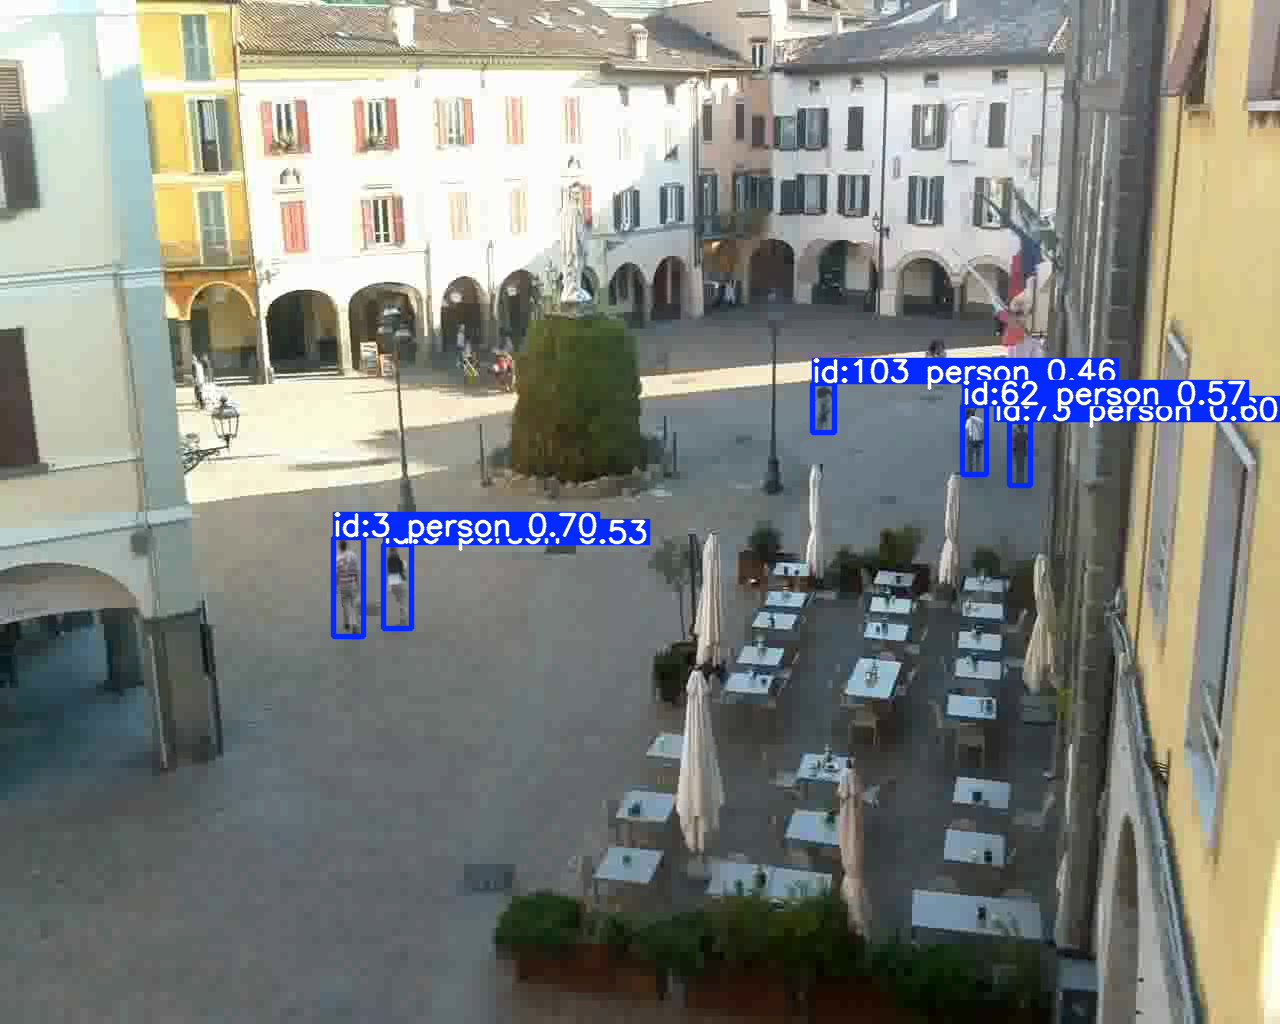

Tracking complete. Results saved to /Users/kanxuanhe/Document/250421_AI_course/ccai9012/starter_kits/4_cv_models/webcam_yolo/output


,frame,id,x1,y1,x2,y2
0,0,1,86.935654,769.614319,132.187576,884.825500
1,0,2,51.777321,769.004272,91.232918,893.318726
2,0,3,352.970581,979.043640,402.730591,1023.480286
3,0,4,615.638855,534.641785,638.167664,609.842102
4,0,5,687.771790,353.340729,710.674377,411.254913
...,...,...,...,...,...,...
1495,224,3,333.170502,537.861389,363.679657,636.641541
1496,224,62,962.238708,405.511932,986.328308,474.298676
1497,224,6,383.211975,544.037048,411.395325,628.114502
1498,224,73,1009.487793,421.310425,1030.828003,485.283630


In [5]:
video_dir = base_dir / "video" / "nuclear_test_15.mp4"
output_dir = base_dir / "output"
yolo_utils.detect_and_track(video_dir, model, output_dir)

In [7]:
# CSV Output Explanation:
# The CSV file 'yolo_track_results.csv' contains one row per detected object per frame.
# Each row includes the following columns:
#
# - frame:        The index of the video frame where the detection occurred (0-based).
# - id:           The tracking ID assigned by ByteTrack.
#                 Objects with the same ID across frames are considered the same tracked person.
#                 An ID of -1 indicates that no stable tracking ID was assigned (e.g., early frames or low confidence).
# - x1, y1:       The coordinates of the top-left corner of the bounding box (in pixels).
# - x2, y2:       The coordinates of the bottom-right corner of the bounding box (in pixels).
#
# These coordinates are relative to the resolution of the original input frame.

df_test = pd.read_csv(str(output_dir / "nuclear_test_15_results.csv"))
df_test

,frame,id,x1,y1,x2,y2
0,0,1,86.935654,769.614319,132.187576,884.825500
1,0,2,51.777321,769.004272,91.232918,893.318726
2,0,3,352.970581,979.043640,402.730591,1023.480286
3,0,4,615.638855,534.641785,638.167664,609.842102
4,0,5,687.771790,353.340729,710.674377,411.254913
...,...,...,...,...,...,...
1495,224,3,333.170502,537.861389,363.679657,636.641541
1496,224,62,962.238708,405.511932,986.328308,474.298676
1497,224,6,383.211975,544.037048,411.395325,628.114502
1498,224,73,1009.487793,421.310425,1030.828003,485.283630


## Step 2: Read a webcam video and clip

Trim the video to a short clip to reduce processing time. Check that the input path exists and confirm the clip duration.

The provided `cam_iseo.mp4` is the default source; the next cell writes a short teaching clip under the Starter Kit output folder. Check the displayed duration and file path before processing more frames.


In [9]:
# The repository includes cam_iseo.mp4; work from that supplied clip.
from moviepy import VideoFileClip
source_video = base_dir / "video" / "cam_iseo.mp4"
clip = VideoFileClip(str(source_video)).subclipped(0, 60)
clip_path = base_dir / "output" / "cam_iseo_teaching_clip.mp4"
clip_path.parent.mkdir(parents=True, exist_ok=True)
clip.write_videofile(str(clip_path), fps=1, codec="mpeg4", audio=False)
clip.close()

MoviePy - Building video /Users/kanxuanhe/Document/250421_AI_course/ccai9012/starter_kits/4_cv_models/webcam_yolo/output/cam_iseo_teaching_clip.mp4.
MoviePy - Writing video /Users/kanxuanhe/Document/250421_AI_course/ccai9012/starter_kits/4_cv_models/webcam_yolo/output/cam_iseo_teaching_clip.mp4



MoviePy - Done !
MoviePy - video ready /Users/kanxuanhe/Document/250421_AI_course/ccai9012/starter_kits/4_cv_models/webcam_yolo/output/cam_iseo_teaching_clip.mp4


## Step 3: Run YOLO to detect and track pedestrian in the clip and save the results

Detect and track objects frame by frame. Results are written to the file specified in the code. A tracking ID may change after an object is occluded.

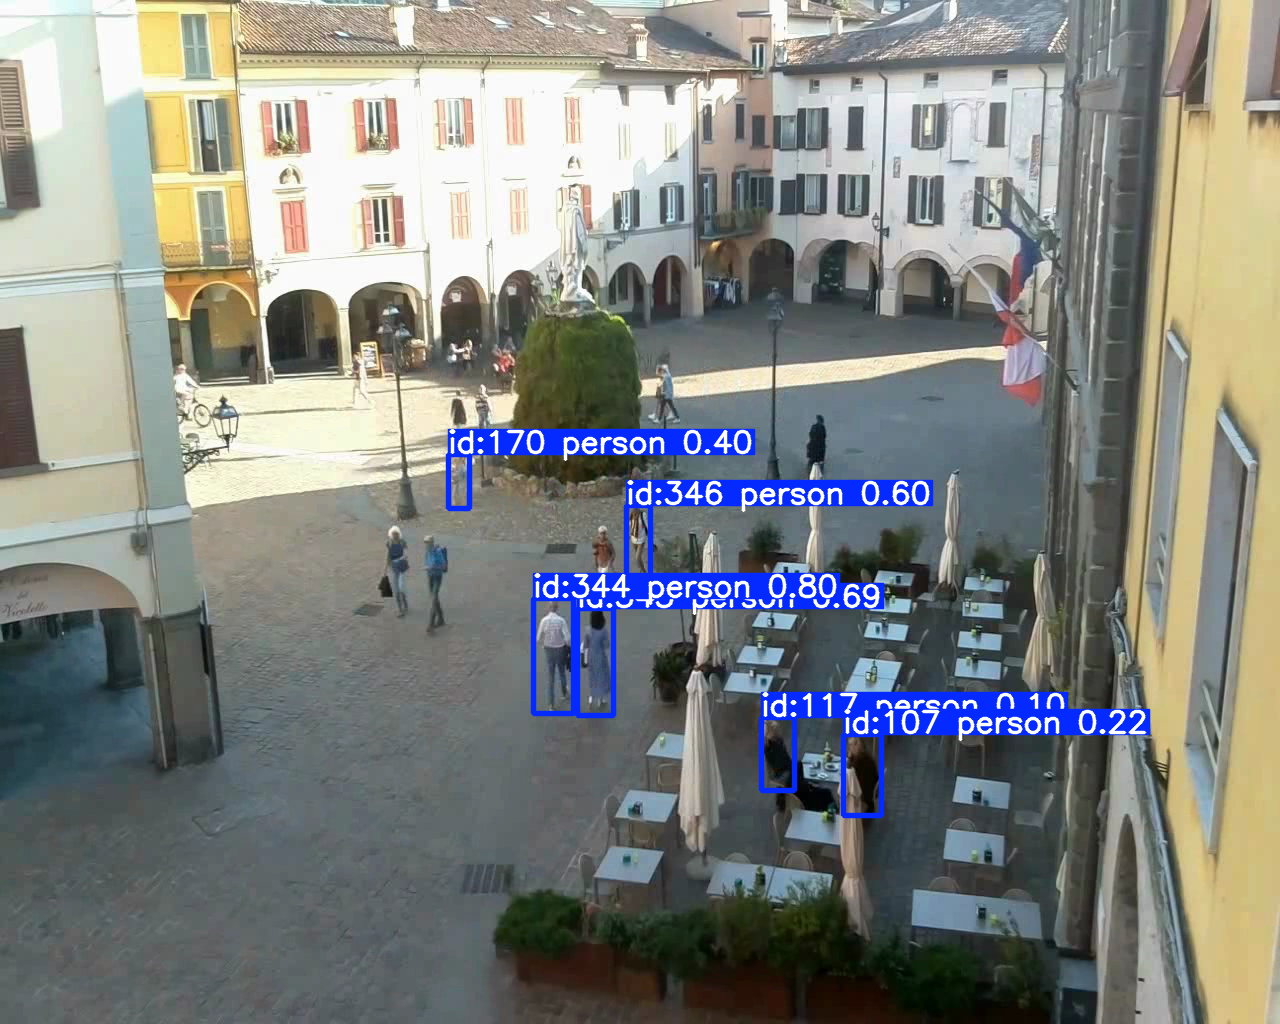

Tracking complete. Results saved to /Users/kanxuanhe/Document/250421_AI_course/ccai9012/starter_kits/4_cv_models/webcam_yolo/output


,frame,id,x1,y1,x2,y2
0,0,-1,0.242771,737.467346,41.392071,834.570374
1,0,-1,430.299377,382.579651,464.259705,442.156067
2,0,-1,844.236328,733.919373,880.879883,811.825378
3,0,-1,758.037842,719.715942,790.776611,784.813354
4,0,-1,460.737183,334.797607,474.606140,373.520447
...,...,...,...,...,...,...
277,59,117,761.776855,717.343872,794.171326,790.743042
278,59,170,448.436890,454.020172,469.439056,508.470642
279,59,344,533.001343,598.480469,573.176025,713.361816
280,59,345,577.377441,608.364258,613.155212,715.090881


In [11]:
video_dir = clip_path
output_dir = base_dir / "output"
yolo_utils.detect_and_track(video_dir, model, output_dir)

## Step 4: Visualize pedestrian footprint heatmap and trajectories

The heatmap shows where objects appear often; a trajectory shows the path of one tracking ID. Coordinates depend on the video frame dimensions.

**Read the graphics:** A dense patch shows many recorded detections in these frames, not necessarily more unique people. Compare it with the annotated clip to spot stationary cameras, missed detections, and ID switches.


In [13]:
# Load CSV
df = pd.read_csv(str(base_dir / "output" / "cam_iseo_teaching_clip_results.csv"))

# Calculate bottom center point of each bounding box
df['x_center'] = (df['x1'] + df['x2']) / 2
df['y_bottom'] = df['y2']  # Use bottom edge for vertical coordinate

In [15]:
# save a frame from the video as background
import cv2

video_path = str(clip_path)
frame_number = 10  # the one-minute, 1-fps clip has about 60 frames
viz_dir = output_dir / "viz"
viz_dir.mkdir(parents=True, exist_ok=True)
background_img_path = viz_dir / "bg_frame.jpg"

cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Could not read the selected background frame")
cv2.imwrite(str(background_img_path), frame)

True

In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import seaborn as sns

# Load CSV and calculate bottom center point
df = pd.read_csv(str(base_dir / "output" / "cam_iseo_teaching_clip_results.csv"))
df['x_center'] = (df['x1'] + df['x2']) / 2
df['y_bottom'] = df['y2']

# Load background image
bg_img = mpimg.imread(background_img_path)
height, width = bg_img.shape[:2]

/opt/anaconda3/envs/ccai9012/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


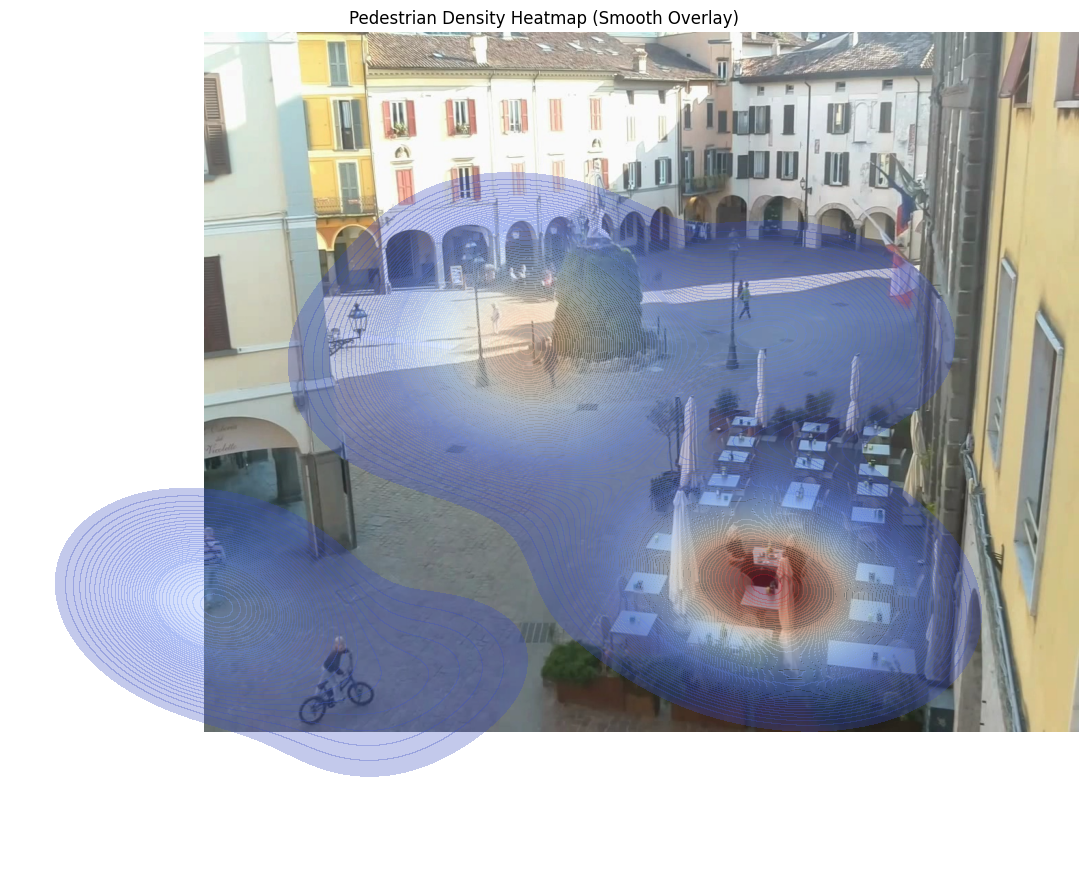

In [19]:
# Visualize pedestrian footprint heatmap

plt.figure(figsize=(12, 9))

# Show background image with transparency
plt.imshow(bg_img, extent=[0, width, height, 0], alpha=0.9)

# KDE heatmap with smooth blending and no white contour lines
sns.kdeplot(
    x=df['x_center'],
    y=df['y_bottom'],
    fill=True,              # fill area under KDE
    cmap="coolwarm",            # smooth color map
    bw_adjust=1.0,          # bandwidth
    levels=100,             # more levels = smoother gradient
    alpha=0.3,              # transparency of the heatmap
    thresh=0.02,            # remove low-density noise
    linewidths=0            # no contour lines (white borders)
)

plt.title("Pedestrian Density Heatmap (Smooth Overlay)")
plt.axis('off')
plt.tight_layout()
plt.savefig(viz_dir / "heatmap_overlay.png", dpi=300)
plt.show()

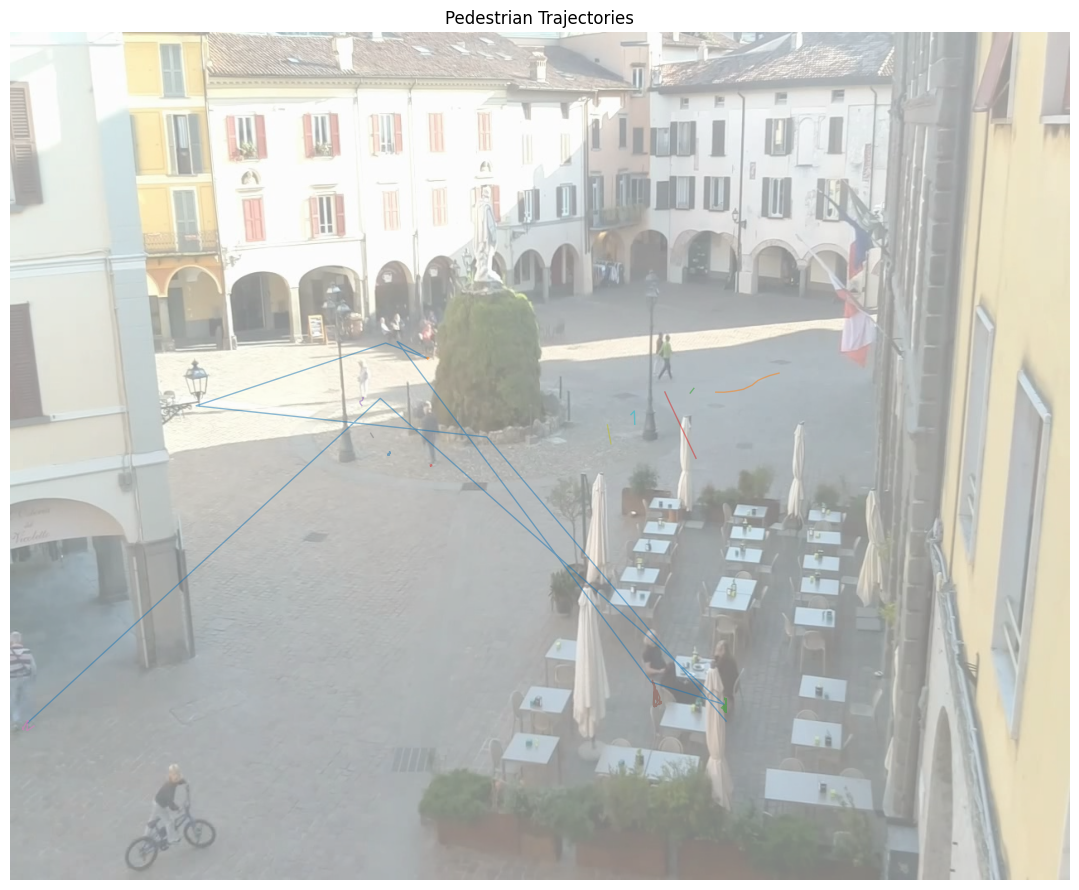

In [21]:
# Pedestrian Trajectories
plt.figure(figsize=(12, 9))

# Show background image
plt.imshow(bg_img, extent=[0, width, height, 0], alpha=0.5)

# Draw each trajectory
for pid, group in df.groupby("id"):
    plt.plot(group['x_center'], group['y_bottom'], linewidth=1, alpha=0.5)

plt.title("Pedestrian Trajectories")
plt.axis('off')
plt.tight_layout()
plt.savefig(viz_dir / "trajectory_overlay.png", dpi=300)
plt.show()

## Step 5: Generate a visualizing clip

Draw detection boxes on the video and play it to check false detections, missed detections, and ID changes.

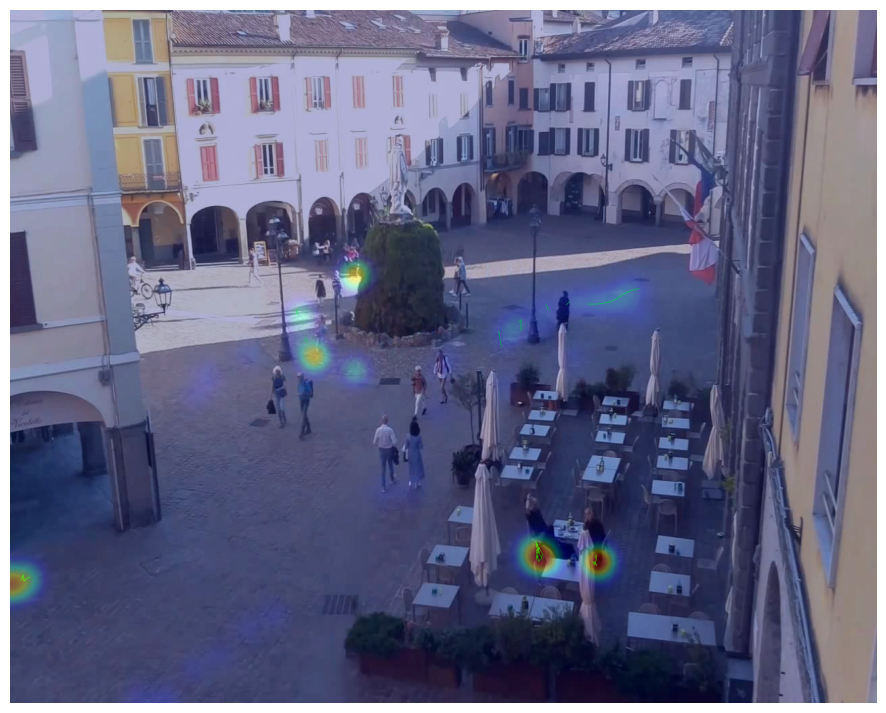

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

...

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

In [23]:
yolo_utils.visualize_video(
    input_csv=str(base_dir / "output" / "cam_iseo_teaching_clip_results.csv"),
    input_video=str(clip_path),
    output_video=str(viz_dir / "cam_iseo_viz.mp4"),
    show_window=True
)

## What to take away

Boxes and trajectories are the model’s estimates from video frames. **Try next:** Use another short video and check it by eye. **Limit:** Occlusion, camera angle, and image quality can cause missed detections or tracking errors.